Importing data from csv. This data presents the number of daily users for Washington DC's bikeshare system for two years along with a large set of calendar and weather information for each day. When exploring the variables involved, there is one date variable, with the rest being ints or floats representing categorical (season, holiday, weekday, workingday, and weathersit) or quantitative (day, month, year, temp, atemp, humidity, windspeed, casual riders, registered riders, and total riders) variables. Holiday and workingday are booleans (is it a holiday and is it a work day), weekday ranges from 0-6 representing Sunday-Saturday, there are 4 seasons (1-winter, 2-spring, 3-summer, 4-fall), and 3 types of weather (1-clear, 2-light precipitation, 3-heavy precipitation).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import os

data_path = "/content/drive/MyDrive/Colab Notebooks/day.csv"

# List files
df = pd.read_csv(data_path)
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
(731, 16)
<class 'pandas.c

Validating that the number of casual riders (pay-by-ride users) plus the number of registered riders (monthly passholders) equals the total number of riders for a given day

In [33]:
for index, row in df.iterrows():
  print('Day ' + str(row['instant']))
  print(row['casual'])
  print(row['registered'])
  print(row['casual'] + row['registered'])
  print(row['cnt'])

Day 1.0
331.0
654.0
985.0
985.0
Day 2.0
131.0
670.0
801.0
801.0
Day 3.0
120.0
1229.0
1349.0
1349.0
Day 4.0
108.0
1454.0
1562.0
1562.0
Day 5.0
82.0
1518.0
1600.0
1600.0
Day 6.0
88.0
1518.0
1606.0
1606.0
Day 7.0
148.0
1362.0
1510.0
1510.0
Day 8.0
68.0
891.0
959.0
959.0
Day 9.0
54.0
768.0
822.0
822.0
Day 10.0
41.0
1280.0
1321.0
1321.0
Day 11.0
43.0
1220.0
1263.0
1263.0
Day 12.0
25.0
1137.0
1162.0
1162.0
Day 13.0
38.0
1368.0
1406.0
1406.0
Day 14.0
54.0
1367.0
1421.0
1421.0
Day 15.0
222.0
1026.0
1248.0
1248.0
Day 16.0
251.0
953.0
1204.0
1204.0
Day 17.0
117.0
883.0
1000.0
1000.0
Day 18.0
9.0
674.0
683.0
683.0
Day 19.0
78.0
1572.0
1650.0
1650.0
Day 20.0
83.0
1844.0
1927.0
1927.0
Day 21.0
75.0
1468.0
1543.0
1543.0
Day 22.0
93.0
888.0
981.0
981.0
Day 23.0
150.0
836.0
986.0
986.0
Day 24.0
86.0
1330.0
1416.0
1416.0
Day 25.0
186.0
1799.0
1985.0
1985.0
Day 26.0
34.0
472.0
506.0
506.0
Day 27.0
15.0
416.0
431.0
431.0
Day 28.0
38.0
1129.0
1167.0
1167.0
Day 29.0
123.0
975.0
1098.0
1098.0
Day 30.0
140.0

Dropping the date variable because it is a difficult datatype to work with and all of the calendar data is coded into other variables (instant/day, month, year)

In [3]:
df = df.drop('dteday', axis=1)
print(df.head())

   instant  season  yr  mnth  holiday  weekday  workingday  weathersit  \
0        1       1   0     1        0        6           0           2   
1        2       1   0     1        0        0           0           2   
2        3       1   0     1        0        1           1           1   
3        4       1   0     1        0        2           1           1   
4        5       1   0     1        0        3           1           1   

       temp     atemp       hum  windspeed  casual  registered   cnt  
0  0.344167  0.363625  0.805833   0.160446     331         654   985  
1  0.363478  0.353739  0.696087   0.248539     131         670   801  
2  0.196364  0.189405  0.437273   0.248309     120        1229  1349  
3  0.200000  0.212122  0.590435   0.160296     108        1454  1562  
4  0.226957  0.229270  0.436957   0.186900      82        1518  1600  


Creating initial visualizations to understand which variables do and do not affect system usage

In [42]:
sns.pairplot(df)

Output hidden; open in https://colab.research.google.com to view.

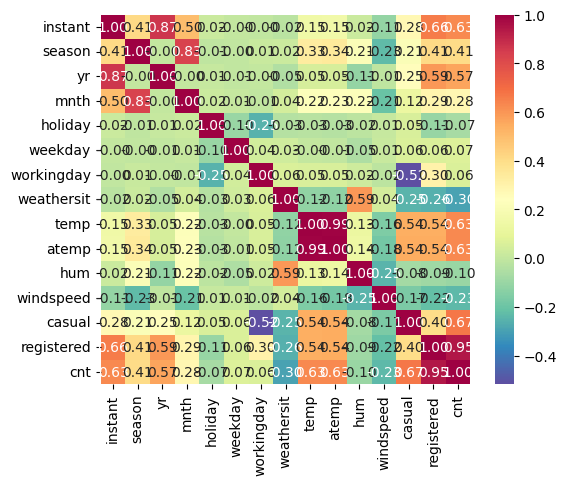

In [45]:
corrmat = df.corr()
hm = sns.heatmap(corrmat,
                 cbar=True,
                 annot=True,
                 square=True,
                 fmt='.2f',
                 annot_kws={'size': 10},
                 yticklabels=df.columns,
                 xticklabels=df.columns,
                 cmap="Spectral_r")
plt.show()

Dropping the temperature variable (it is nearly identical to the atemp variable which just records the feeling temperature instead) and the holiday, weekday, and humidity variables that show almost no correlation with system usage (registered, casual, and total users), which is the set of features the exploratory data analysis tries to understand the best.

In [4]:
df = df.drop('temp', axis=1)
df = df.drop('holiday', axis=1)
df = df.drop('weekday', axis=1)
df = df.drop('hum', axis=1)
print(df.head())

   instant  season  yr  mnth  workingday  weathersit     atemp  windspeed  \
0        1       1   0     1           0           2  0.363625   0.160446   
1        2       1   0     1           0           2  0.353739   0.248539   
2        3       1   0     1           1           1  0.189405   0.248309   
3        4       1   0     1           1           1  0.212122   0.160296   
4        5       1   0     1           1           1  0.229270   0.186900   

   casual  registered   cnt  
0     331         654   985  
1     131         670   801  
2     120        1229  1349  
3     108        1454  1562  
4      82        1518  1600  


Recreating initial visualizations without the extraneous data

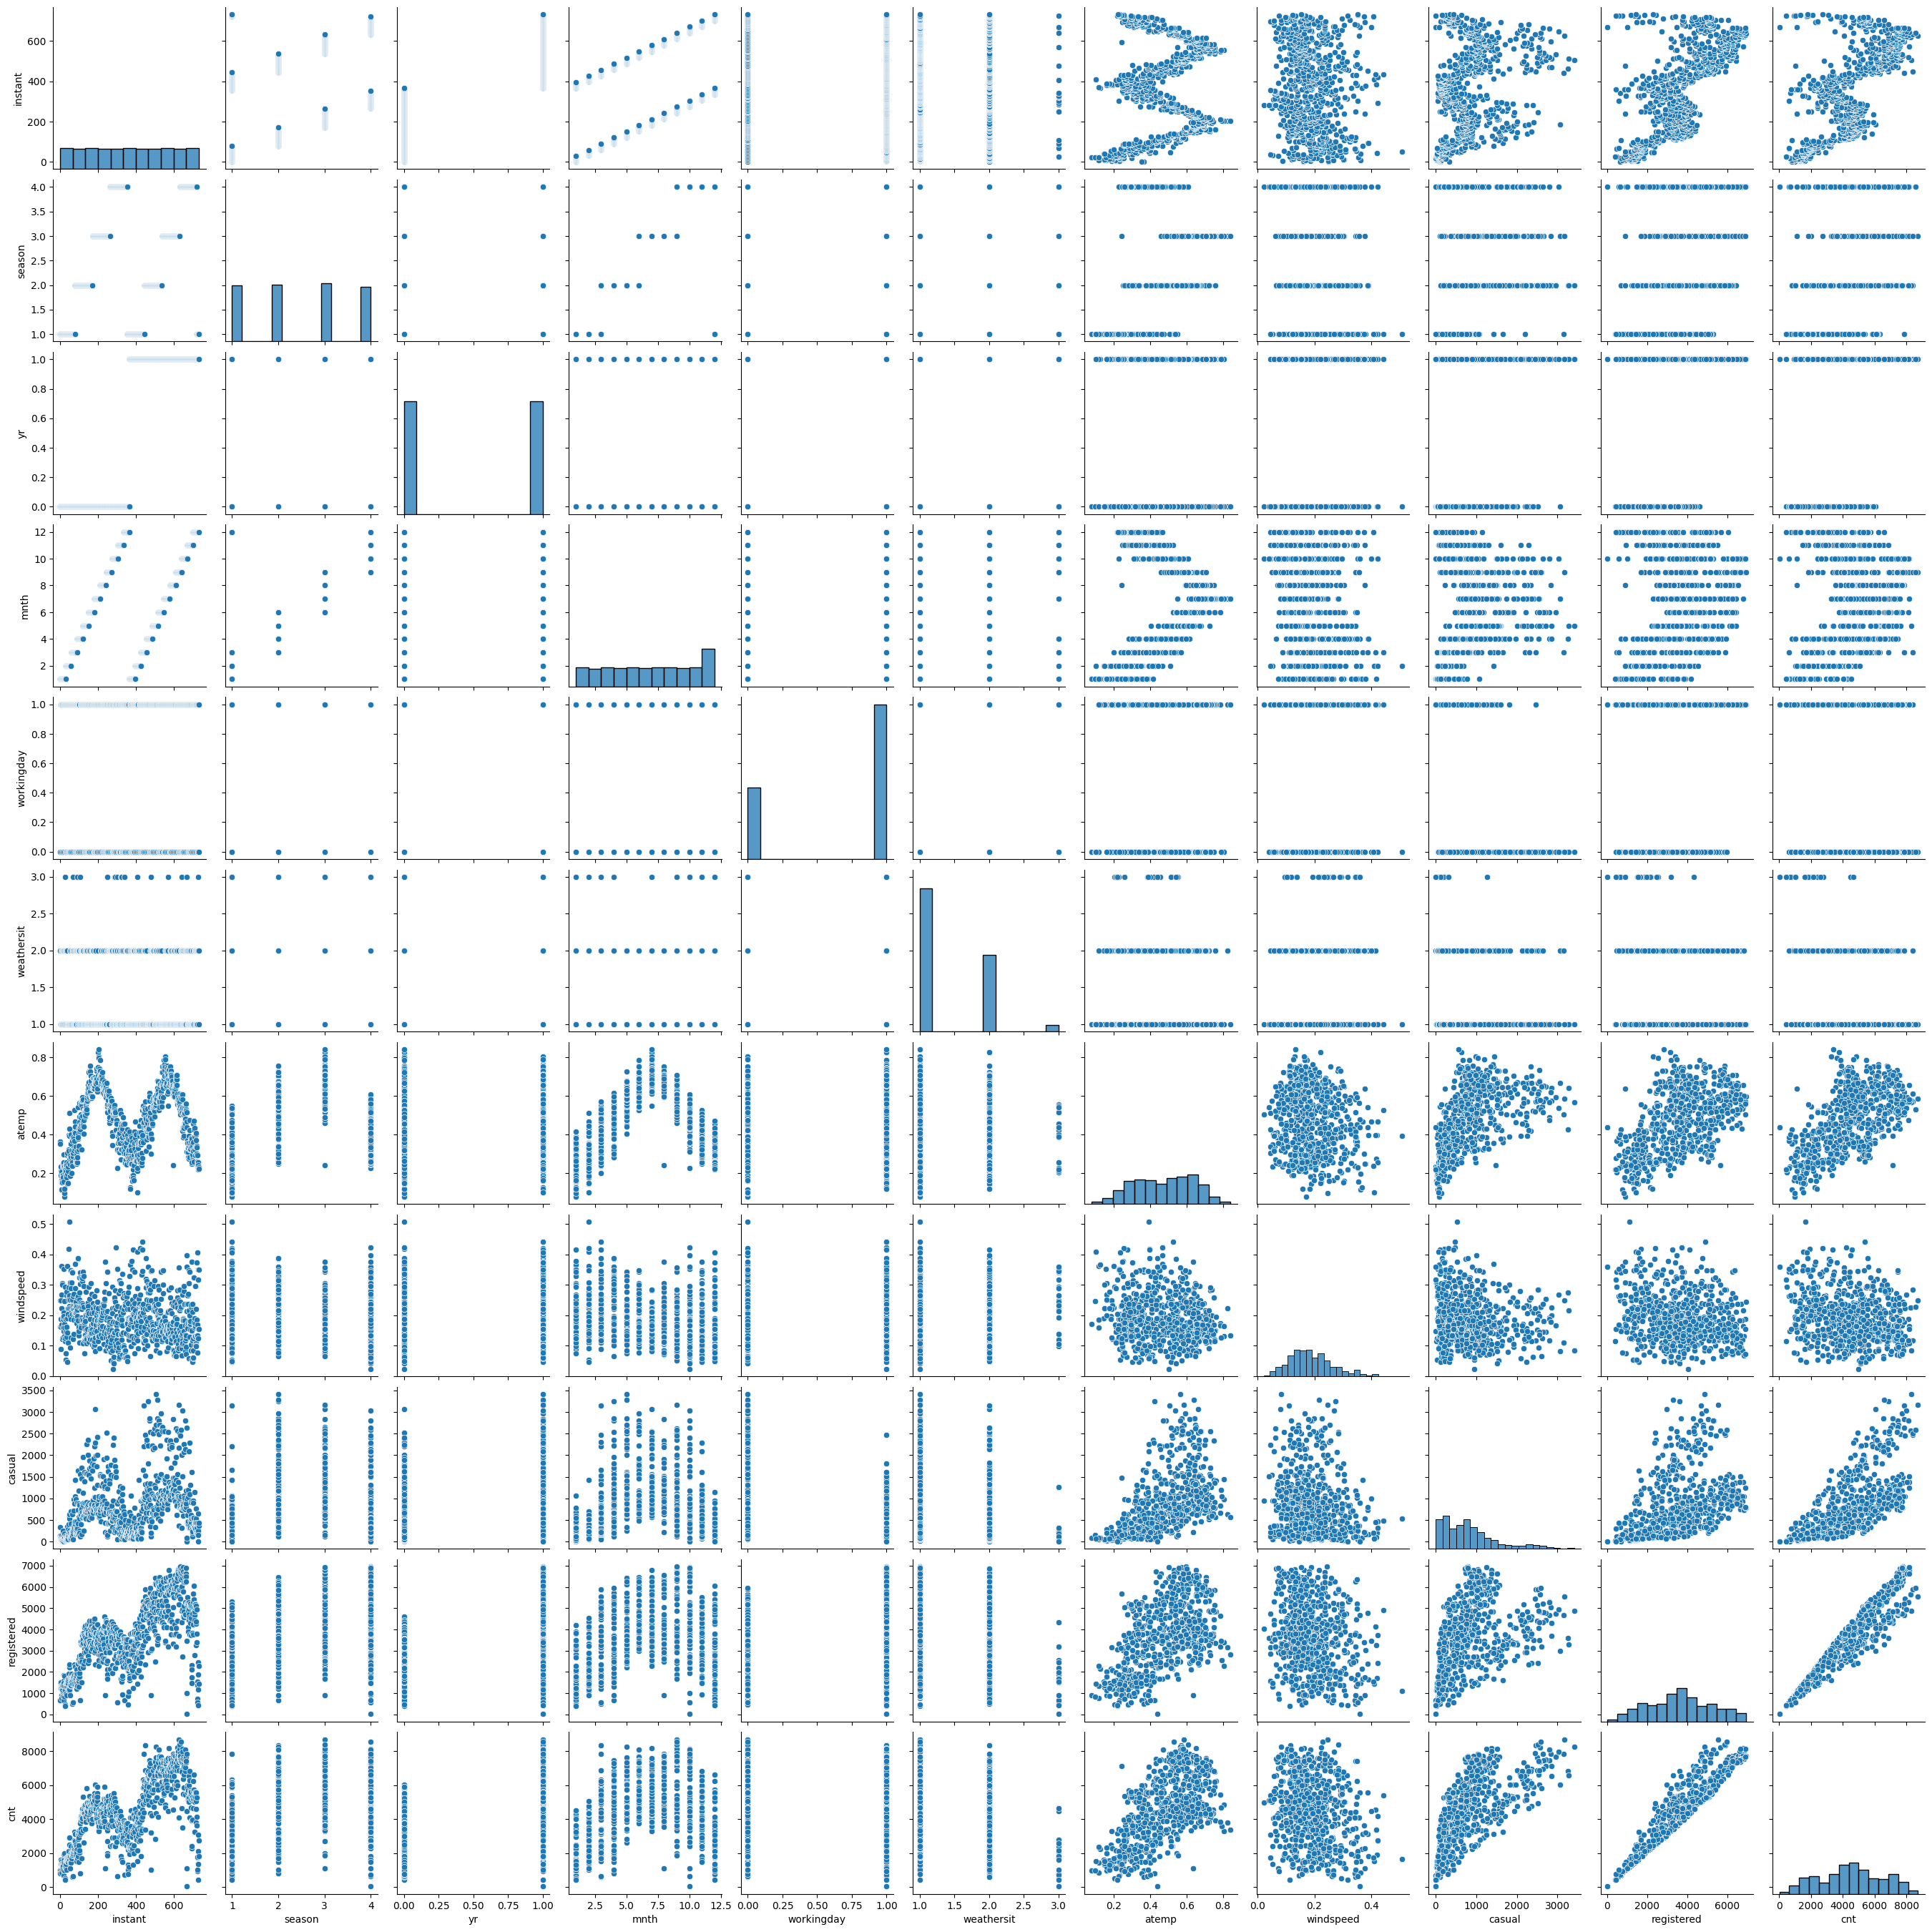

In [47]:
sns.pairplot(df)

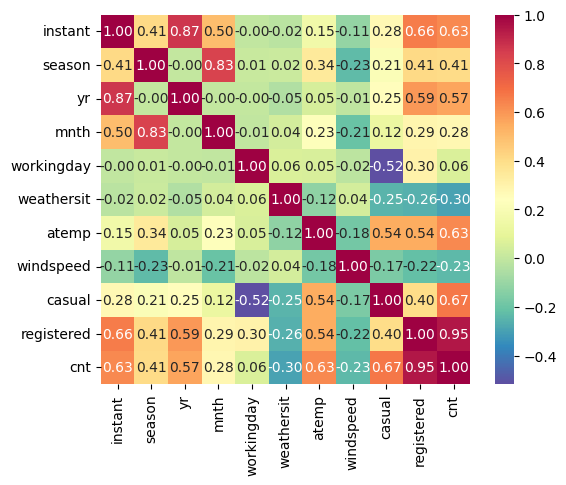

In [48]:
corrmat = df.corr()
hm = sns.heatmap(corrmat,
                 cbar=True,
                 annot=True,
                 square=True,
                 fmt='.2f',
                 annot_kws={'size': 10},
                 yticklabels=df.columns,
                 xticklabels=df.columns,
                 cmap="Spectral_r")
plt.show()

Investigating the effects of weather situation on usage; severe weather deters riders but light weather generally does not compared to clear days

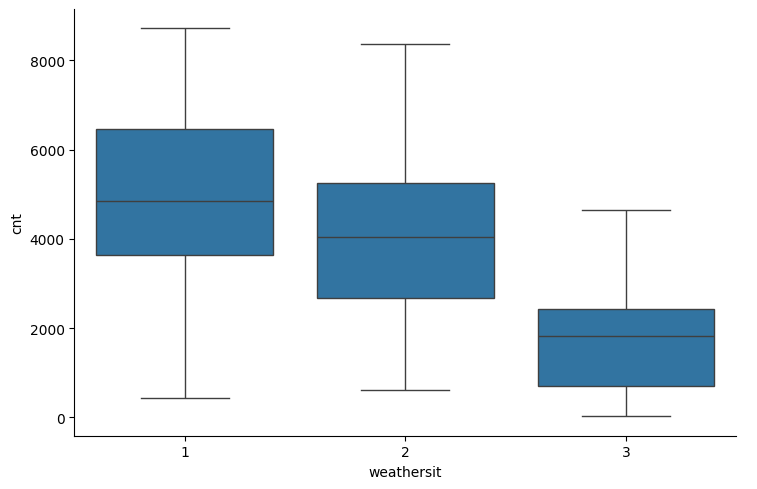

In [49]:
sns.catplot(x="weathersit", y="cnt", data=df, kind="box", aspect=1.5)
plt.show()

Investigating the effects of weather and temperature on usage; usage generally increases with temperature and decreases with severe weather

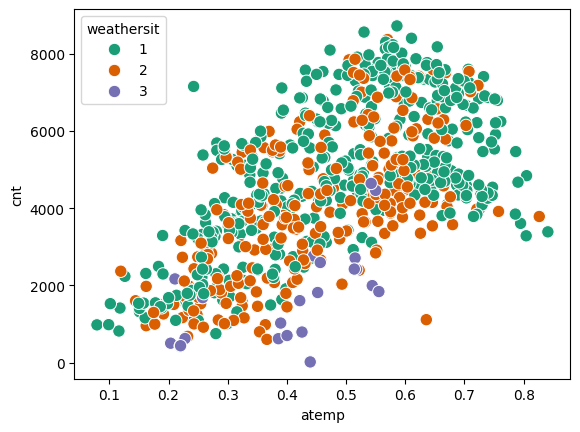

In [50]:
sns.scatterplot(x="atemp", y="cnt", hue="weathersit", data=df, palette="Dark2", s=80)
plt.show()

Noting the general trend of usage over the two-year period; summer peaks are clear though usage is overall higher during the second year with higher peaks on working days for registered users and nonworking days for casual users

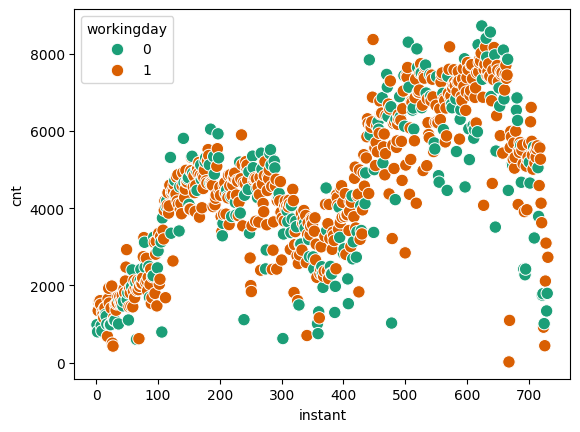

In [9]:
sns.scatterplot(x="instant", y="cnt", hue="workingday", data=df, palette="Dark2", s=80)
plt.show()

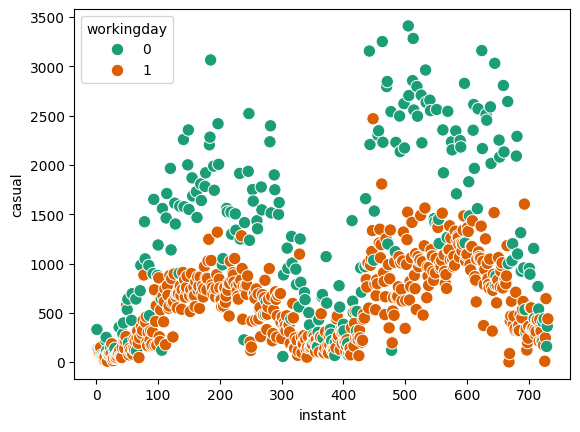

In [10]:
sns.scatterplot(x="instant", y="casual", hue="workingday", data=df, palette="Dark2", s=80)
plt.show()

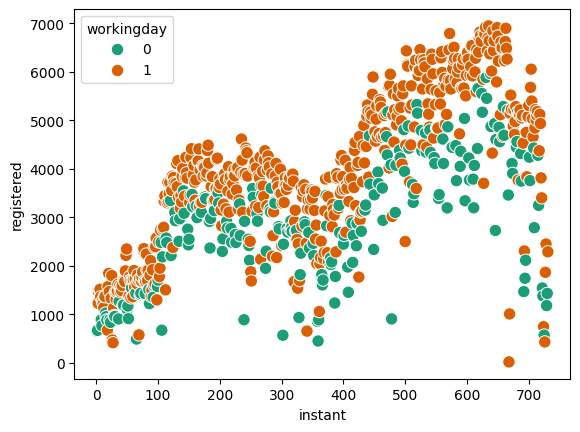

In [11]:
sns.scatterplot(x="instant", y="registered", hue="workingday", data=df, palette="Dark2", s=80)
plt.show()

While windspeed is not greatly correlated with usage, usage is noticably higher in the summer and lower in the winter, which is unsurprising

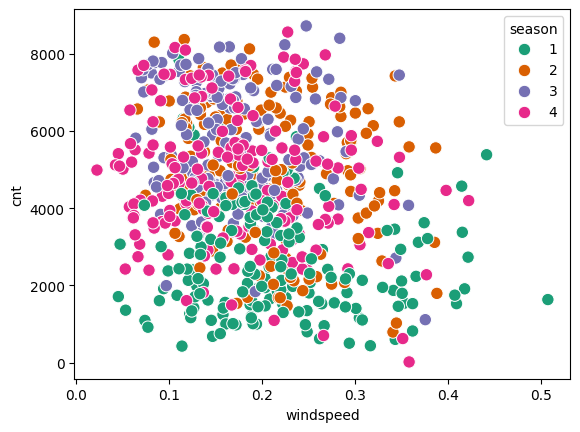

In [14]:
sns.scatterplot(x="windspeed", y="cnt", hue="season", data=df, palette="Dark2", s=80)
plt.show()

Temperature is moderately correlated with usage overall, though the working day/non-working day is much more distinct with casual users

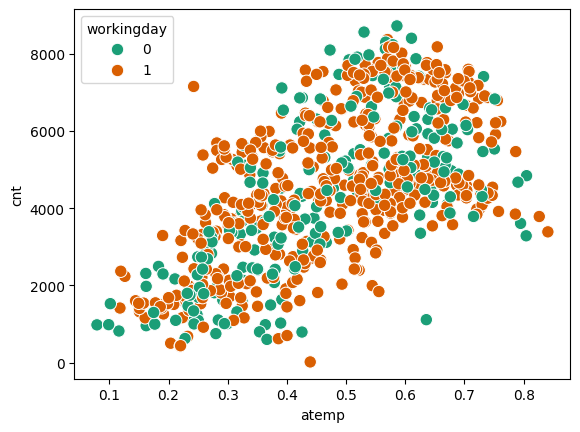

In [15]:
sns.scatterplot(x="atemp", y="cnt", hue="workingday", data=df, palette="Dark2", s=80)
plt.show()

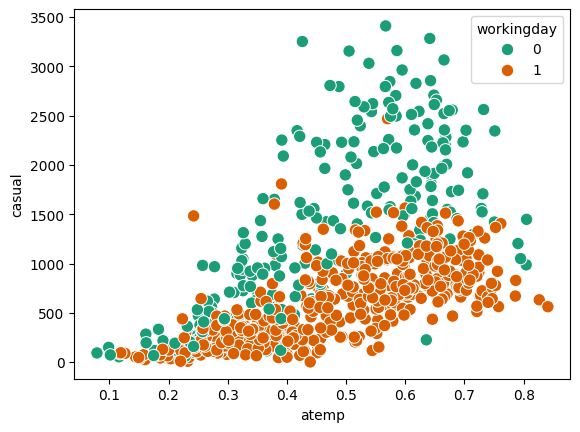

In [53]:
sns.scatterplot(x="atemp", y="casual", hue="workingday", data=df, palette="Dark2", s=80)
plt.show()

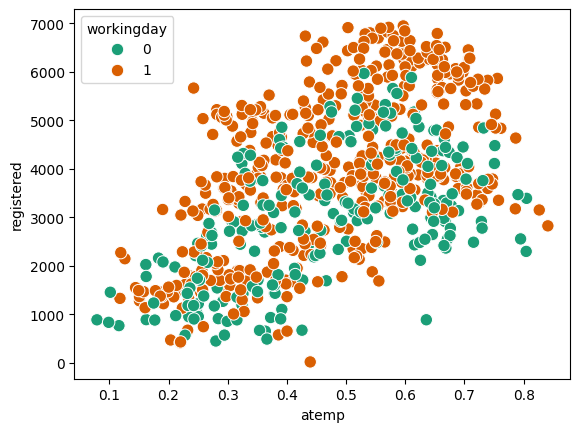

In [54]:
sns.scatterplot(x="atemp", y="registered", hue="workingday", data=df, palette="Dark2", s=80)
plt.show()

There are two distinct relationships between casual and registered users; on work days the number of registered riders rises much faster compared to casual users, while on non-work days the number of casual users is much higher

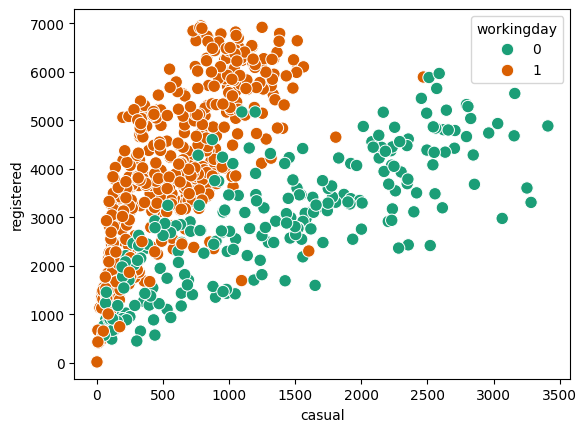

In [55]:
sns.scatterplot(x="casual", y="registered", hue="workingday", data=df, palette="Dark2", s=80)
plt.show()

With a baseline understanding of relationships between variables, it makes sense to perform linear or polynomial regresssion for these quantitative response variables, though since two distinct values are being predicted for any given day of usage (registered users and casual users), it makes sense to build two different models and sum their outputs to estimate the total number of riders for a given day (especially given that registered users make up a majority of riders). For the regression, important explanitory variables include season (slight positive correlation), year (positive correlation), working day (negative correlation for casual users), weather situation (negative correlation), temperature (positive correlation), wind speed (slight negative correlation), and month (can be modeled using a quadratic with linear and quadratic parameters, and serves as a better feature than day since it has a discrete range of 1-12 whereas day just keeps increasing, forcing the use of a sinusoidal model).